In [23]:
# ============================================================================
# CELL 1: IMPORTS AND SETUP
# ============================================================================

import torch
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
import deep_sdf.workspace as ws
import networks.sdf_vae as vae
import json
import time
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA, FastICA, NMF, FactorAnalysis
from sklearn.manifold import LocallyLinearEmbedding, TSNE, SpectralEmbedding
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Set up paths for supervised model
experiment_directory = "examples/hippocampus_MS"  # Changed from hippocampus_healthy

# Load specs
specs = ws.load_experiment_specifications(experiment_directory)
data_source = specs["DataSource"]
data_source_mesh = specs["DataSourceMesh"]
train_split_file = specs["TrainSplit"]

# Model parameters
latent_size = specs["CodeLength"]
num_samp_per_scene = specs["SamplesPerScene"]
decoder_specs = specs["NetworkSpecs"]
kl_div_loss = False

print("="*60)
print("AGE-SUPERVISED HIPPOCAMPUS LATENT ANALYSIS")
print("="*60)
print(f"Latent size: {latent_size}")
print(f"Supervised dimension: z[1] (age)")

AGE-SUPERVISED HIPPOCAMPUS LATENT ANALYSIS
Latent size: 16
Supervised dimension: z[1] (age)


In [18]:
# ============================================================================
# CELL 2: MODEL LOADING AND LATENT EXTRACTION
# ============================================================================

def load_supervised_model_and_extract_latents():
    """Load supervised model and extract latent variables for all training data"""
    
    # Load supervised model from hippocampus_MS
    decoder = vae.SDFVAE(latent_size, num_samp_per_scene, decoder_specs, kl_div_loss).cuda()
    
    model_file = os.path.join(experiment_directory, "ModelParameters", "2000.pth")
    if os.path.exists(model_file):
        print(f"Loading supervised model from: {model_file}")
        saved_model_state = torch.load(model_file)
        decoder.load_state_dict(saved_model_state["model_state_dict"])
        decoder.eval()
        print("Supervised model loaded successfully!")
    else:
        raise FileNotFoundError(f"Model file not found: {model_file}")
    
    # Load training data
    with open(train_split_file, "r") as f:
        train_split = json.load(f)
    
    # Get training filenames
    import deep_sdf.data as data
    eval_train_filenames = data.get_instance_filenames(data_source, train_split)
    
    # Load labels
    labels_path = os.path.join(data_source, "labels.pt")
    all_labels = torch.load(labels_path)
    
    # Extract latents for each training sample
    all_latents = []
    all_ages = []
    all_diseases = []
    filenames = []
    
    print(f"Extracting latents from {len(eval_train_filenames)} training samples...")
    
    with torch.no_grad():
        for i, train_fname in enumerate(eval_train_filenames):
            if i % 50 == 0:
                print(f"Processing {i}/{len(eval_train_filenames)}")
                
            save_name = os.path.basename(train_fname).split(".npz")[0]
            mesh_path = os.path.join(data_source_mesh, save_name + ".obj")
            
            # Get surface points
            surface_points = data.get_surface_points(mesh_path)
            surface_points = torch.from_numpy(surface_points).unsqueeze(0).cuda()
            
            # Extract latent using encoder
            if kl_div_loss:
                mu, logvar = decoder.encoder(surface_points)
                latent = mu
            else:
                latent = decoder.encoder(surface_points)
            
            all_latents.append(latent.cpu().numpy().squeeze())
            
            # Get labels
            if save_name in all_labels:
                label = all_labels[save_name]
                all_ages.append(float(label[0].item()))
                all_diseases.append(int(label[1].item()))
            else:
                print(f"Warning: No label found for {save_name}")
                all_ages.append(0.0)
                all_diseases.append(0)
            
            filenames.append(save_name)
    
    latents_array = np.stack(all_latents, axis=0)
    print(f"Extracted latents shape: {latents_array.shape}")
    
    return {
        'latents': latents_array,
        'ages': np.array(all_ages),
        'diseases': np.array(all_diseases),
        'filenames': filenames,
        'decoder': decoder
    }

# Extract latents from supervised model
print("="*60)
print("EXTRACTING LATENTS FROM SUPERVISED MODEL")
print("="*60)

supervised_data = load_supervised_model_and_extract_latents()

# Save the extracted latents
save_dir = os.path.join(experiment_directory, "supervised_age_analysis")
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "supervised_latents.npy"), supervised_data['latents'])
np.save(os.path.join(save_dir, "ages.npy"), supervised_data['ages'])
np.save(os.path.join(save_dir, "diseases.npy"), supervised_data['diseases'])

print(f"Saved latents to: {save_dir}")
print(f"Supervised latents shape: {supervised_data['latents'].shape}")

EXTRACTING LATENTS FROM SUPERVISED MODEL
Loading supervised model from: examples/hippocampus_MS/ModelParameters/2000.pth
Supervised model loaded successfully!
Extracting latents from 196 training samples...
Processing 0/196
Processing 50/196
Processing 50/196
Processing 100/196
Processing 100/196
Processing 150/196
Processing 150/196
Extracted latents shape: (196, 16)
Saved latents to: examples/hippocampus_MS/supervised_age_analysis
Supervised latents shape: (196, 16)
Extracted latents shape: (196, 16)
Saved latents to: examples/hippocampus_MS/supervised_age_analysis
Supervised latents shape: (196, 16)


ANALYSIS OF SUPERVISED Z[1] FOR AGE
Data statistics:
  Supervised latents: (196, 16)
  Ages: (196,), range: [0.3, 0.8]
  Diseases: (196,), unique: [0 1]

Supervised dimension z[1] analysis:
  Age correlation: -0.8475
  Disease correlation: 0.0817
  |Age correlation|: 0.8475

Disentanglement Quality:
  ✅ Good disentanglement: High age correlation, low disease correlation

Age Disentanglement Metrics (Full Analysis):
  Best R²: z[1] = 0.7182 (r = -0.8475)
  Second best R²: z[14] = 0.1756 (r = -0.4191)
  SAP Score (age): 0.5426 [using R² as per literature]
  ✅ z[1] is the best age predictor as expected!

Disease Correlation Analysis (All Dimensions):
--------------------------------------------------
Disease correlation in non-supervised dimensions:
  z[0]: R² = 0.5410, r = -0.7355
  z[7]: R² = 0.0190, r = 0.1377
  z[10]: R² = 0.0155, r = -0.1243
  z[5]: R² = 0.0103, r = 0.1014
  z[14]: R² = 0.0089, r = 0.0945
  SAP Score (disease, excl. z[1]): 0.5220
  Top disease-correlated dims: z[0, 7

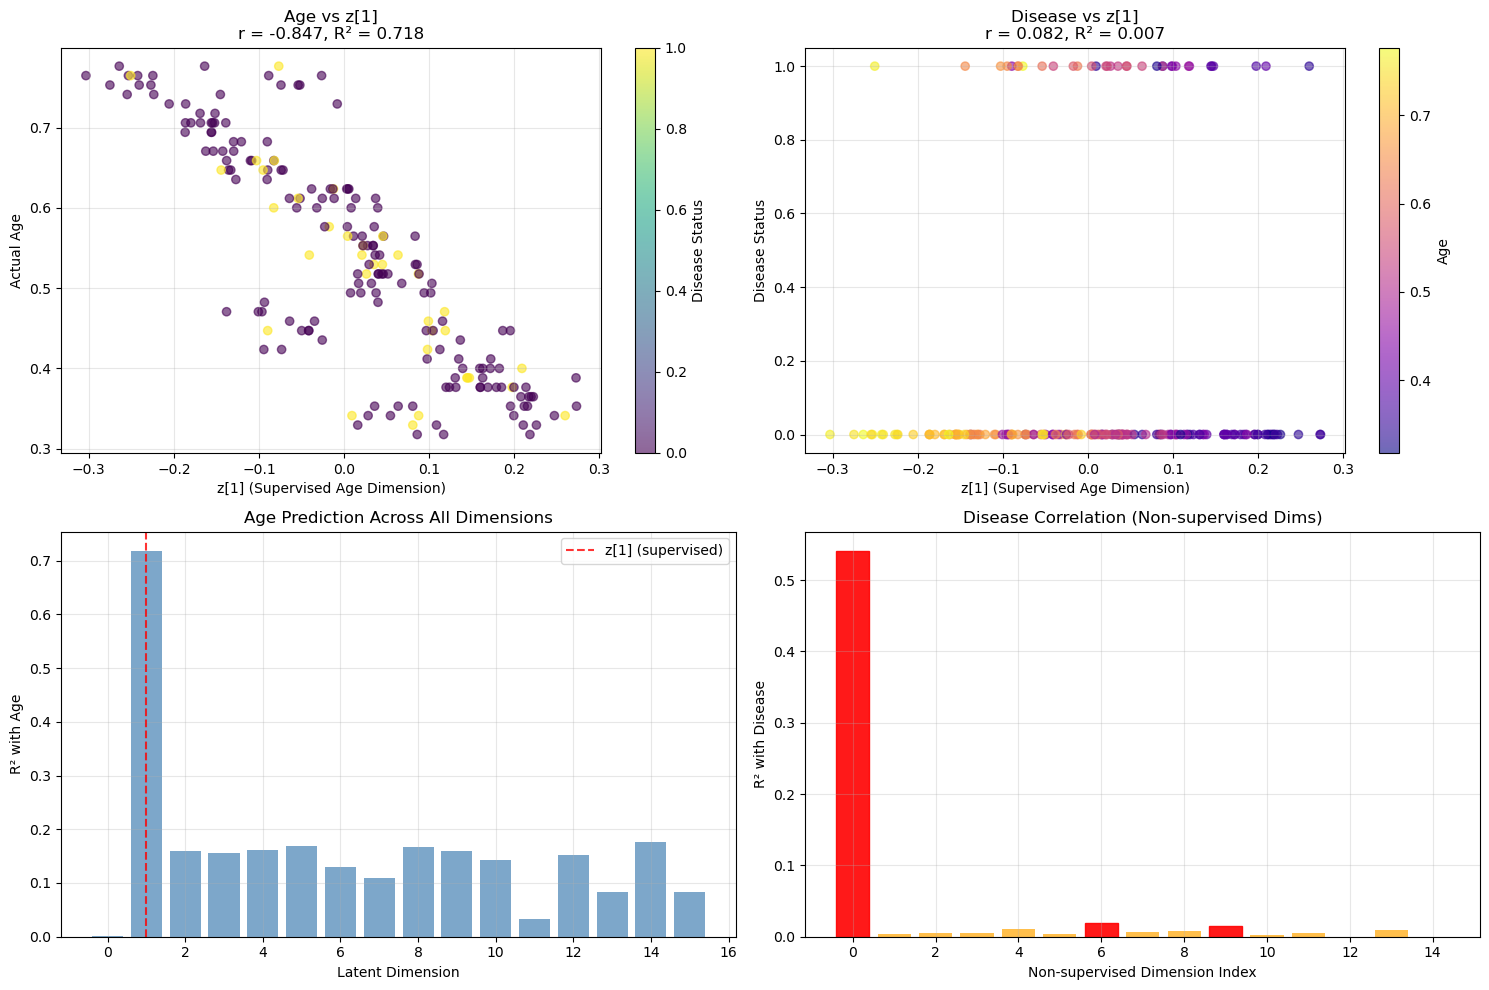


DETAILED CORRELATION ANALYSIS
Age Supervision Quality:
  z[1] → Age: r = -0.8475, R² = 0.7182
  z[1] → Disease: r = 0.0817, R² = 0.0067
  SAP Score (Age): 0.5426
  SAP Score (Disease, non-sup): 0.5220

Top Age-Predictive Dimensions:
  z[1]: R² = 0.7182
  z[14]: R² = 0.1756
  z[5]: R² = 0.1680

Top Disease-Predictive Dimensions (excluding z[1]):
  z[0]: R² = 0.5410
  z[7]: R² = 0.0190
  z[10]: R² = 0.0155


In [19]:
# ============================================================================
# CELL 3: ANALYSIS OF SUPERVISED Z[1] FOR AGE
# ============================================================================

# Get the data
Z_s = supervised_data['latents']  # Supervised latents (N, 16)
ages = supervised_data['ages']
diseases = supervised_data['diseases']

print("="*60)
print("ANALYSIS OF SUPERVISED Z[1] FOR AGE")
print("="*60)

# Basic statistics
print(f"Data statistics:")
print(f"  Supervised latents: {Z_s.shape}")
print(f"  Ages: {ages.shape}, range: [{ages.min():.1f}, {ages.max():.1f}]")
print(f"  Diseases: {diseases.shape}, unique: {np.unique(diseases)}")

# Focus on z[1] - the supervised age dimension
z1_age_correlation, _ = pearsonr(Z_s[:, 1], ages)
z1_disease_corr, _ = pearsonr(Z_s[:, 1], diseases)

print(f"\nSupervised dimension z[1] analysis:")
print(f"  Age correlation: {z1_age_correlation:.4f}")
print(f"  Disease correlation: {z1_disease_corr:.4f}")
print(f"  |Age correlation|: {abs(z1_age_correlation):.4f}")

# Check if z[1] is good age predictor and poor disease predictor
print(f"\nDisentanglement Quality:")
if abs(z1_age_correlation) > 0.5 and abs(z1_disease_corr) < 0.3:
    print(f"  ✅ Good disentanglement: High age correlation, low disease correlation")
elif abs(z1_age_correlation) > 0.5:
    print(f"  ⚠️ High age correlation but also correlates with disease")
else:
    print(f"  ❌ Poor age correlation - supervision may not be working well")

# Store for later analysis
age_corrs = np.zeros(Z_s.shape[1])  # Initialize for compatibility
age_corrs[1] = z1_age_correlation  # Only store z[1] correlation

# Calculate correlations and R² for all dimensions with age
age_corrs_all = np.zeros(Z_s.shape[1])
age_r2_all = np.zeros(Z_s.shape[1])

for i in range(Z_s.shape[1]):
    corr, _ = pearsonr(Z_s[:, i], ages)
    age_corrs_all[i] = corr
    age_r2_all[i] = corr ** 2  # R² = correlation²

# Calculate SAP score using R² (as per literature: "Disentangling by Factorising" - Higgins et al.)
# SAP measures how well the most informative latent variable predicts the attribute
# compared to the second most informative
sorted_r2_indices = np.argsort(age_r2_all)[::-1]  # descending order
sap_score_age = age_r2_all[sorted_r2_indices[0]] - age_r2_all[sorted_r2_indices[1]] if Z_s.shape[1] > 1 else age_r2_all[sorted_r2_indices[0]]

print(f"\nAge Disentanglement Metrics (Full Analysis):")
print(f"  Best R²: z[{sorted_r2_indices[0]}] = {age_r2_all[sorted_r2_indices[0]]:.4f} (r = {age_corrs_all[sorted_r2_indices[0]]:.4f})")
print(f"  Second best R²: z[{sorted_r2_indices[1]}] = {age_r2_all[sorted_r2_indices[1]]:.4f} (r = {age_corrs_all[sorted_r2_indices[1]]:.4f})")
print(f"  SAP Score (age): {sap_score_age:.4f} [using R² as per literature]")

# Check if z[1] is indeed the best age predictor
best_age_dim = sorted_r2_indices[0]
if best_age_dim == 1:
    print(f"  ✅ z[1] is the best age predictor as expected!")
else:
    print(f"  ⚠️  z[{best_age_dim}] is better than z[1] for age prediction")

# Disease correlation analysis for all dimensions
print(f"\nDisease Correlation Analysis (All Dimensions):")
print("-" * 50)
disease_corrs_all = np.zeros(Z_s.shape[1])
disease_r2_all = np.zeros(Z_s.shape[1])

for i in range(Z_s.shape[1]):
    corr, _ = pearsonr(Z_s[:, i], diseases)
    disease_corrs_all[i] = corr
    disease_r2_all[i] = corr ** 2

# Find dimensions most correlated with disease (excluding z[1])
non_supervised_dims = [i for i in range(Z_s.shape[1]) if i != 1]
disease_r2_others = disease_r2_all[non_supervised_dims]
sorted_disease_indices = np.argsort(disease_r2_others)[::-1]  # descending

print(f"Disease correlation in non-supervised dimensions:")
for i in range(min(5, len(sorted_disease_indices))):  # Top 5
    dim_idx = non_supervised_dims[sorted_disease_indices[i]]
    print(f"  z[{dim_idx}]: R² = {disease_r2_all[dim_idx]:.4f}, r = {disease_corrs_all[dim_idx]:.4f}")

# Calculate SAP score for disease (excluding z[1])
sap_score_disease = disease_r2_others[sorted_disease_indices[0]] - disease_r2_others[sorted_disease_indices[1]] if len(sorted_disease_indices) > 1 else disease_r2_others[sorted_disease_indices[0]]
print(f"  SAP Score (disease, excl. z[1]): {sap_score_disease:.4f}")

# Store best disease-correlated dimensions for later analysis
best_disease_dims = [non_supervised_dims[i] for i in sorted_disease_indices[:3]]  # Top 3
print(f"  Top disease-correlated dims: z{best_disease_dims}")

# Visualize age vs z[1] and disease correlation analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age vs z[1] scatter plot
scatter1 = axes[0, 0].scatter(Z_s[:, 1], ages, alpha=0.6, c=diseases, cmap='viridis')
axes[0, 0].set_xlabel('z[1] (Supervised Age Dimension)')
axes[0, 0].set_ylabel('Actual Age')
axes[0, 0].set_title(f'Age vs z[1]\nr = {z1_age_correlation:.3f}, R² = {z1_age_correlation**2:.3f}')
axes[0, 0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0, 0])
cbar1.set_label('Disease Status')

# Disease vs z[1] scatter plot to show separation
scatter2 = axes[0, 1].scatter(Z_s[:, 1], diseases, alpha=0.6, c=ages, cmap='plasma')
axes[0, 1].set_xlabel('z[1] (Supervised Age Dimension)')
axes[0, 1].set_ylabel('Disease Status')  
axes[0, 1].set_title(f'Disease vs z[1]\nr = {z1_disease_corr:.3f}, R² = {z1_disease_corr**2:.3f}')
axes[0, 1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[0, 1])
cbar2.set_label('Age')

# Age R² across all dimensions
axes[1, 0].bar(range(len(age_r2_all)), age_r2_all, alpha=0.7, color='steelblue')
axes[1, 0].axvline(x=1, color='red', linestyle='--', alpha=0.8, label='z[1] (supervised)')
axes[1, 0].set_xlabel('Latent Dimension')
axes[1, 0].set_ylabel('R² with Age')
axes[1, 0].set_title('Age Prediction Across All Dimensions')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Disease R² for non-supervised dimensions
non_sup_dims = [i for i in range(len(disease_r2_all)) if i != 1]
non_sup_r2 = [disease_r2_all[i] for i in non_sup_dims]
bars = axes[1, 1].bar(range(len(non_sup_r2)), non_sup_r2, alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Non-supervised Dimension Index')
axes[1, 1].set_ylabel('R² with Disease')
axes[1, 1].set_title('Disease Correlation (Non-supervised Dims)')
axes[1, 1].grid(True, alpha=0.3)

# Highlight top 3 disease-correlated dimensions
if len(non_sup_r2) >= 3:
    top_3_indices = np.argsort(non_sup_r2)[-3:]
    for idx in top_3_indices:
        bars[idx].set_color('red')
        bars[idx].set_alpha(0.9)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "comprehensive_correlation_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()

# Print detailed correlation analysis
print(f"\n" + "="*60)
print("DETAILED CORRELATION ANALYSIS")
print("="*60)
print(f"Age Supervision Quality:")
print(f"  z[1] → Age: r = {z1_age_correlation:.4f}, R² = {z1_age_correlation**2:.4f}")
print(f"  z[1] → Disease: r = {z1_disease_corr:.4f}, R² = {z1_disease_corr**2:.4f}")
print(f"  SAP Score (Age): {sap_score_age:.4f}")
print(f"  SAP Score (Disease, non-sup): {sap_score_disease:.4f}")

print(f"\nTop Age-Predictive Dimensions:")
for i in range(min(3, len(sorted_r2_indices))):
    dim = sorted_r2_indices[i]
    print(f"  z[{dim}]: R² = {age_r2_all[dim]:.4f}")

print(f"\nTop Disease-Predictive Dimensions (excluding z[1]):")
for i in range(min(3, len(best_disease_dims))):
    dim = best_disease_dims[i]
    print(f"  z[{dim}]: R² = {disease_r2_all[dim]:.4f}")